# Electronic Sales Data Analysis (Sep 2023 – Sep 2024)

<div style="background: linear-gradient(135deg, #0f172a, #1e293b); padding:22px; border-radius:12px; color:#e2e8f0;">
<b>🎯 Objective:</b> Analyze the electronic sales dataset to evaluate sales performance, detect data quality issues, identify trends, and generate business insights based entirely on the data.<br><br>
<b>📂 Dataset:</b> <code>Electronic_sales_Sep2023-Sep2024.csv</code> — ~20,000 order-line records<br>
<b>🧭 Approach:</b> Overview → Data Quality → Cleaning → EDA → Sales Trend → Correlation → Final Insights & Recommendations
</div>

<div style="background-color:#f8fafc; border:1px solid #e2e8f0; padding:16px 20px; border-radius:10px; margin-top:14px;">
<b>Contents</b>
<ol>
<li>Dataset Overview</li>
<li>Data Quality Summary</li>
<li>Data Cleaning</li>
<li>Exploratory Data Analysis (EDA)</li>
<li>Sales Trend Analysis</li>
<li>Product, Payment & Shipping Analysis</li>
<li>Customer Analysis</li>
<li>Correlation Analysis</li>
<li>Final Insights & Recommendations</li>
</ol>
</div>


## 1. 📥 Dataset Overview
The dataset contains customer demographics, product details, payment methods, shipping methods, ratings, and sales values. This section gives an initial look before any cleaning is applied.

We start by importing the libraries we'll use: `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for static charts, and `plotly.express` for interactive charts. A consistent color palette is set once so every chart in the notebook looks cohesive.

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")
sns.set_palette(["#1d4ed8", "#f97316", "#10b981", "#facc15", "#ef4444", "#0f172a"])
pd.set_option("display.max_columns", None)


Now we load the raw CSV file and preview the first few rows to confirm it read correctly and to get a feel for the columns available.

In [ ]:
import pandas as pd

df = pd.read_excel('/content/Electronic_sales_Sep2023-Sep2024 (3).xlsx')

df['Purchase Date'] = pd.to_datetime(
    df['Purchase Date'],
    unit='D',
    origin='1899-12-30'
)

print(df['Purchase Date'].head(10))
print(df['Purchase Date'].dtype)

0   2024-03-20
1   2024-04-20
2   2023-10-17
3   2024-08-09
4   2024-05-21
5   2024-05-26
6   2024-01-30
7   2024-06-24
8   2023-10-03
9   2024-01-01
Name: Purchase Date, dtype: datetime64[ns]
datetime64[ns]


In [162]:
print(df['Purchase Date'].dtype)

datetime64[ns]


`df.shape` tells us how many rows (orders) and columns (fields) we're working with.

In [163]:
df.shape


(20000, 16)

`df.info()` shows each column's data type and how many non-null values it has — a quick first check for missing data and wrong types.

In [164]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        20000 non-null  int64         
 1   Age                20000 non-null  int64         
 2   Gender             19999 non-null  object        
 3   Loyalty Member     20000 non-null  object        
 4   Product Type       20000 non-null  object        
 5   SKU                20000 non-null  object        
 6   Rating             20000 non-null  int64         
 7   Order Status       20000 non-null  object        
 8   Payment Method     20000 non-null  object        
 9   Total Price        20000 non-null  float64       
 10  Unit Price         20000 non-null  float64       
 11  Quantity           20000 non-null  int64         
 12  Purchase Date      20000 non-null  datetime64[ns]
 13  Shipping Type      20000 non-null  object        
 14  Add-on

`df.describe(include="all")` gives summary statistics for every column: mean/min/max for numbers, and most-frequent value/count for text columns.

In [165]:
df.describe(include="all")


,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
count,20000.000000,20000.000000,19999,20000,20000,20000,20000.000000,20000,20000,20000.000000,20000.000000,20000.000000,20000,20000,15132,20000.000000
unique,NaN,NaN,2,2,5,10,NaN,2,6,NaN,NaN,NaN,NaN,5,75,NaN
top,NaN,NaN,Male,No,Smartphone,TBL345,NaN,Completed,Credit Card,NaN,NaN,NaN,NaN,Standard,Extended Warranty,NaN
freq,NaN,NaN,10164,15657,5978,2062,NaN,13432,5868,NaN,NaN,NaN,NaN,6725,1701,NaN
mean,10483.526550,48.994100,NaN,NaN,NaN,NaN,3.093950,NaN,NaN,3180.133419,578.631867,5.485550,2024-04-18 10:42:18.720000256,NaN,NaN,62.244848
min,1000.000000,18.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,20.750000,20.750000,1.000000,2023-09-24 00:00:00,NaN,NaN,0.000000
25%,5478.000000,33.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,1139.680000,361.180000,3.000000,2024-02-05 00:00:00,NaN,NaN,7.615000
50%,10499.500000,49.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,2534.490000,463.960000,5.000000,2024-04-24 00:00:00,NaN,NaN,51.700000
75%,15504.000000,65.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,4639.600000,791.190000,8.000000,2024-07-08 00:00:00,NaN,NaN,93.842500
max,19998.000000,80.000000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,11396.800000,1139.680000,10.000000,2024-09-23 00:00:00,NaN,NaN,292.770000


A random sample of 5 rows (instead of just the first 5) helps confirm the data looks consistent throughout the file, not just at the top.

In [166]:
df.sample(5)


,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
14472,15031,70,Male,No,Laptop,LTP123,2,Completed,Credit Card,2022.96,674.32,3,2024-09-19,Expedited,Extended Warranty,72.38
13156,13771,45,Male,Yes,Headphones,HDP456,3,Completed,Credit Card,1083.54,361.18,3,2024-02-20,Same Day,"Accessory, Extended Warranty, Accessory",122.31
10997,11828,65,Female,No,Smartphone,SMP234,5,Completed,PayPal,3419.04,1139.68,3,2024-04-21,Same Day,NaN,0.00
17962,18181,66,Female,No,Smartwatch,SWT567,1,Cancelled,Bank Transfer,459.50,459.50,1,2024-09-02,Expedited,"Extended Warranty, Accessory, Extended Warranty",237.12
6389,6735,20,Male,No,Smartwatch,SKU1003,3,Completed,Debit Card,8448.30,844.83,10,2024-03-06,Overnight,NaN,0.00


## 2. 🔍 Data Quality Summary
Before drawing any conclusions, we check the data is trustworthy: missing values, duplicates, data types, and inconsistent category labels.

We start data quality checks with missing values — counting them and expressing each as a percentage of the total rows.

In [167]:
df['Purchase Date'].head(10)

,Purchase Date
0,2024-03-20
1,2024-04-20
2,2023-10-17
3,2024-08-09
4,2024-05-21
5,2024-05-26
6,2024-01-30
7,2024-06-24
8,2023-10-03
9,2024-01-01


In [170]:
missing = df.isnull().sum()
missing_percentage = (missing / len(df) * 100).round(2)

pd.DataFrame({"missing_count": missing, "missing_pct": missing_percentage}).sort_values("missing_pct", ascending=False)


,missing_count,missing_pct
Add-ons Purchased,4868,24.34
Customer ID,0,0.00
Gender,1,0.00
Age,0,0.00
Product Type,0,0.00
SKU,0,0.00
Rating,0,0.00
Loyalty Member,0,0.00
Order Status,0,0.00
Payment Method,0,0.00


> 💡 **Insight:** `Add-ons Purchased` has many missing values, but this simply means the customer bought no add-on — not a data quality problem. We'll fix this label in the cleaning step.

Next we check for fully duplicated rows (the same order recorded twice) and review each column's data type, since some — like `Purchase Date` — are stored as text and will need converting.

In [201]:
print("Duplicate rows:", df.duplicated().sum())
df.dtypes


Duplicate rows: 0


,0
Customer ID,int64
Age,int64
Gender,object
Loyalty Member,object
Product Type,object
SKU,object
Rating,int64
Order Status,object
Payment Method,object
Total Price,float64


Counting missing values isn't enough — text columns can also hide **inconsistent labels**. We print the unique values in every text column to catch spelling/casing mismatches.

In [172]:
# Look at the actual values inside each text column — this is how inconsistent
# labels like "Paypal" vs "PayPal" get caught before they distort any analysis.
for col in df.select_dtypes(include="object").columns:
    print(col, "->", df[col].unique()[:10])


Gender -> ['Male' 'Female' nan]
Loyalty Member -> ['No' 'Yes']
Product Type -> ['Smartphone' 'Tablet' 'Laptop' 'Smartwatch' 'Headphones']
SKU -> ['SKU1004' 'SKU1002' 'SKU1005' 'SKU1001' 'SKU1003' 'LTP123' 'SMP234'
 'TBL345' 'HDP456' 'SWT567']
Order Status -> ['Cancelled' 'Completed']
Payment Method -> ['Credit Card' 'Paypal' 'Cash' 'Debit Card' 'Bank Transfer' 'PayPal']
Shipping Type -> ['Standard' 'Overnight' 'Express' 'Same Day' 'Expedited']
Add-ons Purchased -> ['Accessory,Accessory,Accessory' 'Impulse Item' nan
 'Impulse Item,Impulse Item' 'Accessory' 'Impulse Item,Accessory'
 'Extended Warranty,Extended Warranty'
 'Impulse Item,Accessory,Impulse Item' 'Accessory,Extended Warranty'
 'Extended Warranty,Impulse Item,Extended Warranty']


> 💡 **Insight:** `Payment Method` contains both `"Paypal"` and `"PayPal"` — the same payment method spelled two different ways. Left unfixed, this would silently split one group into two in every summary table.

### 2.1 Outlier Check (IQR method)
Boxplots make outliers easy to spot visually — points drawn outside the "whiskers" are unusually high or low compared to the rest of the column.

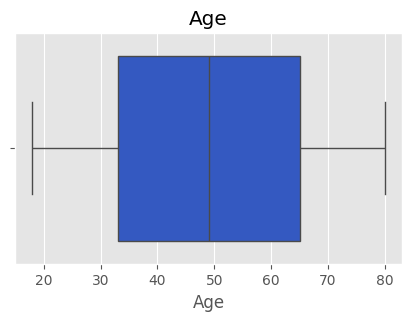

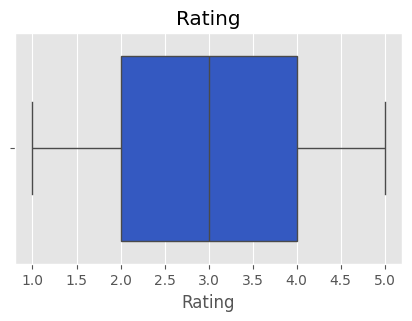

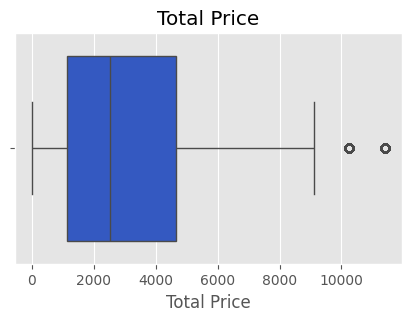

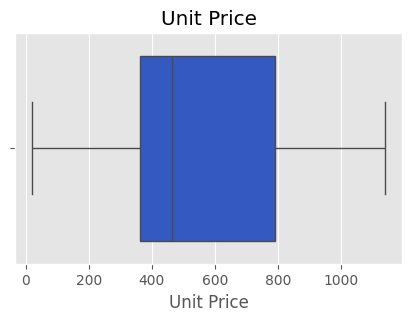

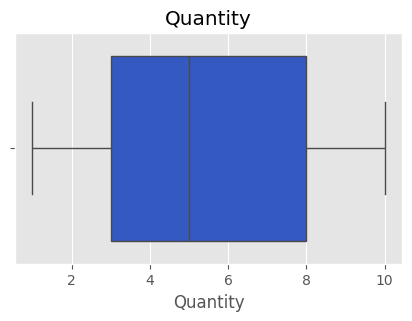

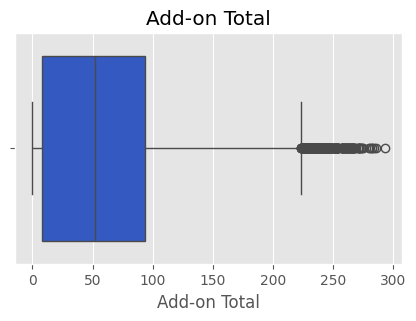

In [173]:
numeric_cols = df.select_dtypes(include=np.number).columns.drop("Customer ID")

for col in numeric_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df[col], color="#1d4ed8")
    plt.title(col)
    plt.show()


We then quantify the outliers in `Total Price` using the IQR (interquartile range) rule: any value more than 1.5×IQR beyond the 25th/75th percentile is flagged as an outlier.

In [174]:
Q1 = df["Total Price"].quantile(0.25)
Q3 = df["Total Price"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Total Price"] < Q1 - 1.5*IQR) | (df["Total Price"] > Q3 + 1.5*IQR)]
print(f"Total Price outliers (IQR method): {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}% of data)")


Total Price outliers (IQR method): 383 rows (1.92% of data)


> 💡 **Insight:** These flagged rows are kept in the dataset — high-value electronics purchases (e.g. laptops) are plausible real transactions, not errors, so we flag rather than delete them.

## 3. 🧹 Data Cleaning

### 3.1 Fix Dates & Extract Month/Year
`Purchase Date` is currently stored as plain text, so it can't be used for time-based analysis yet. We convert it to a real `datetime` type and pull out `Month` and `Year` as separate columns for easy grouping later.

In [175]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
df["Month"] = df["Purchase Date"].dt.to_period("M")
df["Year"] = df["Purchase Date"].dt.year

df[["Purchase Date", "Month", "Year"]].head()


,Purchase Date,Month,Year
0,2024-03-20,2024-03,2024
1,2024-04-20,2024-04,2024
2,2023-10-17,2023-10,2023
3,2024-08-09,2024-08,2024
4,2024-05-21,2024-05,2024


### 3.2 Standardize Payment Method Labels
We found earlier that `"Paypal"` and `"PayPal"` are the same payment method written two ways. We merge them into one consistent label so revenue totals aren't split across two rows.

In [176]:
df["Payment Method"] = df["Payment Method"].replace({"Paypal": "PayPal"})
df["Payment Method"].unique()


array(['Credit Card', 'PayPal', 'Cash', 'Debit Card', 'Bank Transfer'],
      dtype=object)

### 3.3 Handle Missing Values
Each missing value is filled based on what it actually means in context, rather than a generic placeholder:

In [177]:
# "Add-ons Purchased" missing = no add-on bought, not a gap in the data
df["Add-ons Purchased"] = df["Add-ons Purchased"].fillna("None")

# Gender has 1 missing value -> fill with the overall most common value
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df.isnull().sum().sum()  # should be 0


np.int64(0)

### 3.4 Simple Feature Engineering
With the data cleaned, we can derive a couple of useful new columns: how many add-ons were purchased per order, and how much total revenue each customer has generated across all their orders.

In [178]:
# How many add-ons were bought in each order (0 if none)
df["Addon_Count"] = df["Add-ons Purchased"].apply(lambda x: 0 if x == "None" else len(x.split(",")))

# Total revenue per customer (sums across all their orders)
customer_revenue = df.groupby("Customer ID")["Total Price"].sum().rename("Customer_Total_Revenue")
df = df.merge(customer_revenue, on="Customer ID", how="left")

df[["Addon_Count", "Customer_Total_Revenue"]].head()


,Addon_Count,Customer_Total_Revenue
0,3,6279.42
1,1,6279.42
2,0,5020.60
3,2,5020.60
4,1,41.50


> 📌 **Cleaning summary:** dates converted to `datetime`, `Month`/`Year` extracted, `"Paypal"` merged into `"PayPal"`, missing values resolved with business-meaningful defaults, and two useful features added (`Addon_Count`, `Customer_Total_Revenue`).

## 4. 📊 Exploratory Data Analysis (EDA)
How individual variables are distributed, one at a time, before we look at relationships between them.

**Total Price** — a histogram shows how order values are spread out across all transactions.

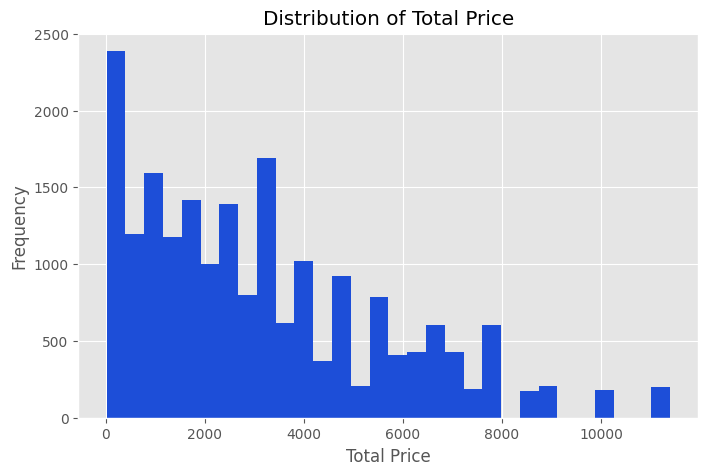

In [179]:
plt.figure(figsize=(8, 5))
plt.hist(df["Total Price"], bins=30, color="#1d4ed8")
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()


> 💡 **Insight:** Most transactions fall within the lower price range, while a smaller number of high-value purchases create a right-skewed distribution.

**Rating** — the same kind of histogram, this time for customer satisfaction scores (1 to 5).

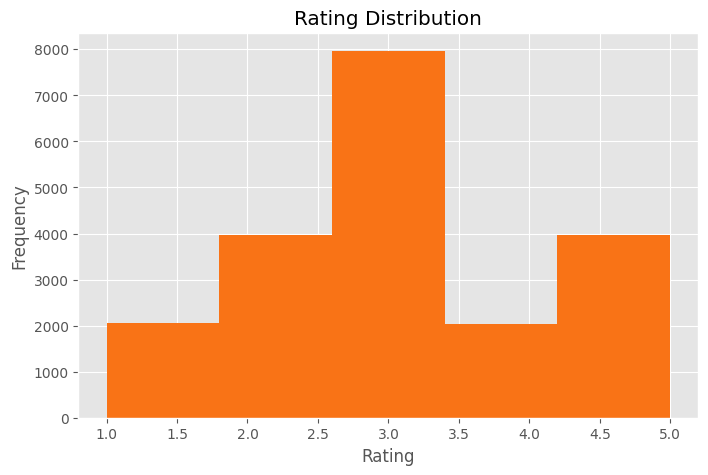

In [180]:
plt.figure(figsize=(8, 5))
plt.hist(df["Rating"], bins=5, color="#f97316")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()


> 💡 **Insight:** Ratings are fairly spread across the scale — satisfaction is not overwhelmingly positive or negative, so there's room to actively improve the customer experience.

**Product Type** — a count plot shows how many orders fall into each product category.

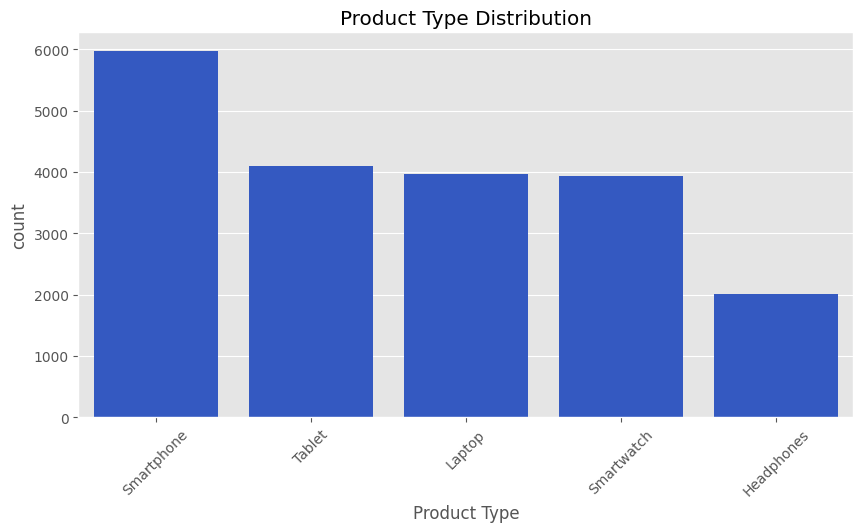

In [181]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Product Type", order=df["Product Type"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Product Type Distribution")
plt.show()


**Order Status** — how many orders were completed vs. cancelled, plus the overall cancellation rate.

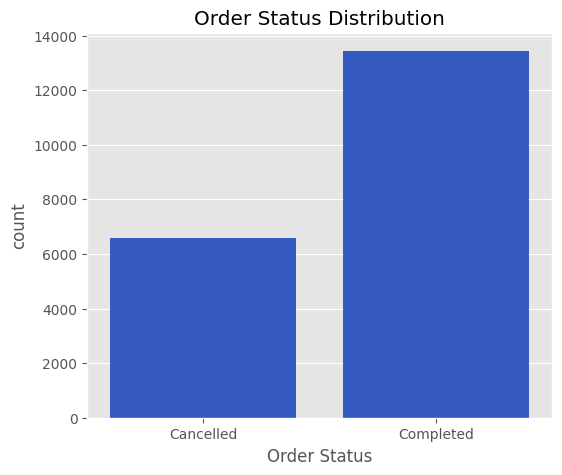

Cancellation rate: 32.84%


In [182]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Order Status")
plt.title("Order Status Distribution")
plt.show()

cancel_rate = (df["Order Status"] == "Cancelled").mean() * 100
print(f"Cancellation rate: {cancel_rate:.2f}%")


> 💡 **Insight:** Some product categories are ordered far more often than others, showing clear differences in customer demand. The cancellation rate is a useful operational KPI to track over time.

**Gender & Loyalty** — interactive pie charts (hover to see exact percentages) for the customer base composition.

In [183]:
fig = px.pie(df, names="Gender", title="Customer Gender Split", hole=0.4,
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_traces(textinfo="percent+label")
fig.show()


In [184]:
fig = px.pie(df, names="Loyalty Member", title="Loyalty Membership Split", hole=0.4,
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_traces(textinfo="percent+label")
fig.show()


> 💡 **Insight:** Interactive charts like these let stakeholders hover for exact percentages — useful when presenting the customer mix live.

## 5. 📈 Sales Trend Analysis
Having looked at individual variables, we now turn to how sales performed over time — the numbers stakeholders usually ask for first.

First, the headline numbers for the whole period.

In [185]:
print("Total Sales   :", round(df["Total Price"].sum(), 2))
print("Average Order :", round(df["Total Price"].mean(), 2))
print("Median Order  :", round(df["Total Price"].median(), 2))
print("Std Deviation :", round(df["Total Price"].std(), 2))


Total Sales   : 63602668.37
Average Order : 3180.13
Median Order  : 2534.49
Std Deviation : 2544.98


### Revenue Impact of Cancelled Orders
Total revenue on its own hides how much of it was actually lost to cancelled orders. Here we split revenue into **Cancelled** vs. **Net (completed)**, and express the loss as a percentage — this is the number that matters for a business case, not just the cancellation rate as a % of order count.

In [186]:
# Revenue lost due to cancelled orders
cancelled_revenue = df.loc[
    df["Order Status"] == "Cancelled",
    "Total Price"
].sum()
total_revenue = df["Total Price"].sum()
net_revenue = total_revenue - cancelled_revenue
loss_percent = (cancelled_revenue / total_revenue) * 100

print(f"Total Revenue      : {total_revenue:,.2f}")
print(f"Cancelled Revenue  : {cancelled_revenue:,.2f}")
print(f"Net Revenue        : {net_revenue:,.2f}")
print(f"Revenue Lost       : {loss_percent:.2f}%")


Total Revenue      : 63,602,668.37
Cancelled Revenue  : 20,973,052.80
Net Revenue        : 42,629,615.57
Revenue Lost       : 32.98%


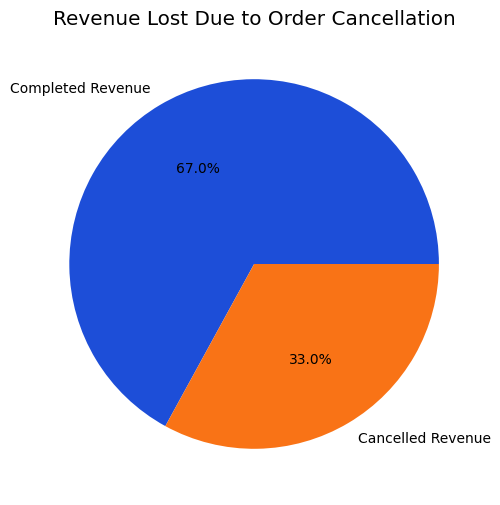

In [187]:
revenue = pd.Series({
    "Completed Revenue": net_revenue,
    "Cancelled Revenue": cancelled_revenue
})

plt.figure(figsize=(6, 6))
revenue.plot(kind="pie", autopct="%1.1f%%")
plt.title("Revenue Lost Due to Order Cancellation")
plt.ylabel("")
plt.show()


> 💡 **Insight:** Cancellations aren't just an operational annoyance — they represent real revenue leaving the business. This pie chart is the clearest way to show a stakeholder exactly what share of revenue is being lost to cancellations.

Grouping by `Month` and summing `Total Price` gives us the monthly sales trend, plotted as a line chart.

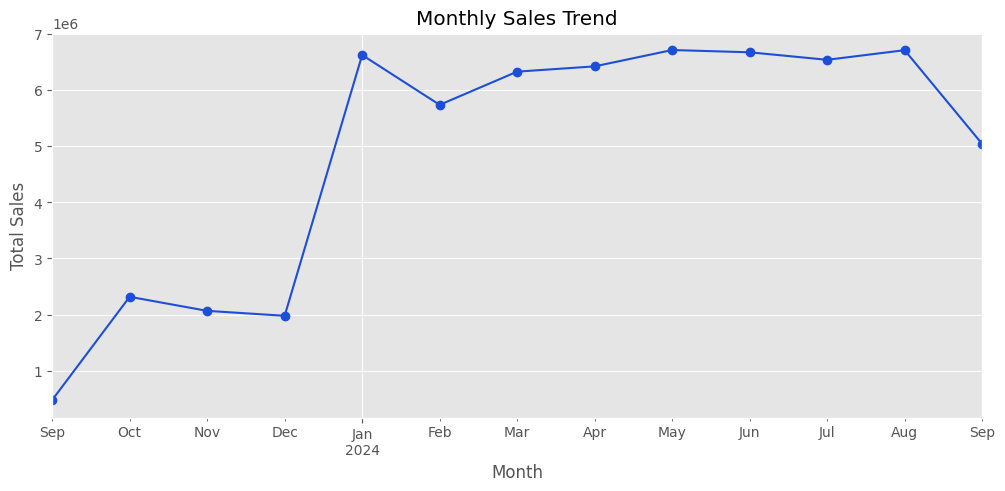

In [188]:
monthly = df.groupby("Month")["Total Price"].sum().sort_index()

plt.figure(figsize=(12, 5))
monthly.plot(marker="o", color="#1d4ed8")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()


From that same monthly series, we pull out the single highest and lowest months.

In [189]:
print("Highest Sales Month:", monthly.idxmax(), "->", round(monthly.max(), 2))
print("Lowest Sales Month :", monthly.idxmin(), "->", round(monthly.min(), 2))


Highest Sales Month: 2024-05 -> 6709042.93
Lowest Sales Month : 2023-09 -> 481961.79


Beyond raw totals, the **month-over-month growth rate** shows whether sales are accelerating or slowing down, which raw totals alone don't make obvious.

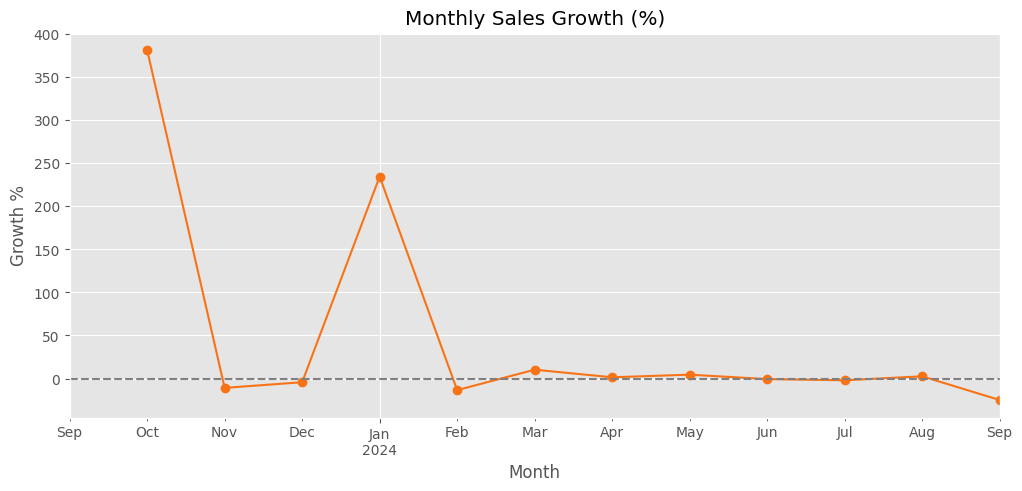

In [190]:
monthly_growth = monthly.pct_change() * 100

plt.figure(figsize=(12, 5))
monthly_growth.plot(marker="o", color="#f97316")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Monthly Sales Growth (%)")
plt.xlabel("Month")
plt.ylabel("Growth %")
plt.grid(True)
plt.show()


> 💡 **Insight:** Monthly sales show clear periods of growth and decline across the year. Peaks indicate high purchasing activity, while drops may reflect seasonal demand or operational issues — growth swinging between positive and negative months confirms demand is seasonal rather than flat.

## 6. 🏷️ Product, Payment & Shipping Analysis
Next we break total revenue down by category to see exactly where the money is coming from.

**Revenue by Product Type** — which categories generate the most total revenue.

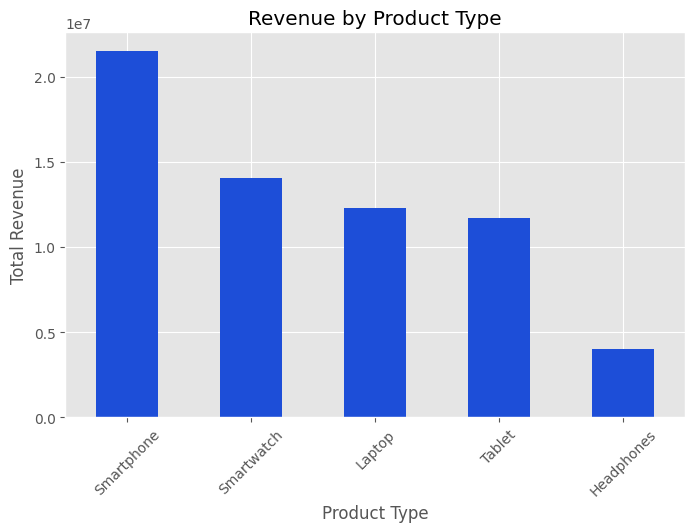

,Total Price
Product Type,
Smartphone,21516754.69
Smartwatch,14036273.06
Laptop,12296239.97
Tablet,11712000.41
Headphones,4041400.24


In [191]:
product_sales = df.groupby("Product Type")["Total Price"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
product_sales.plot(kind="bar", color="#1d4ed8")
plt.title("Revenue by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

product_sales


**Revenue by Payment Method** — shown as a pie chart since we care about each method's share of the total.

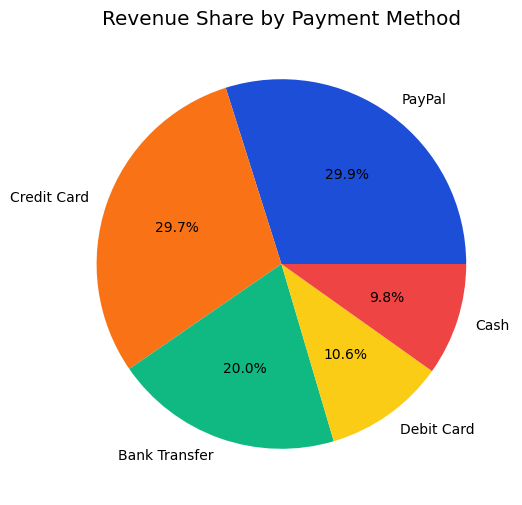

,Total Price
Payment Method,
PayPal,18998843.99
Credit Card,18913772.92
Bank Transfer,12698262.09
Debit Card,6736217.54
Cash,6255571.83


In [192]:
payment_sales = df.groupby("Payment Method")["Total Price"].sum().sort_values(ascending=False)

payment_sales.plot(kind="pie", autopct="%1.1f%%", figsize=(6, 6))
plt.title("Revenue Share by Payment Method")
plt.ylabel("")
plt.show()

payment_sales


**Revenue by Shipping Type** — which shipping option customers use most, by revenue generated.

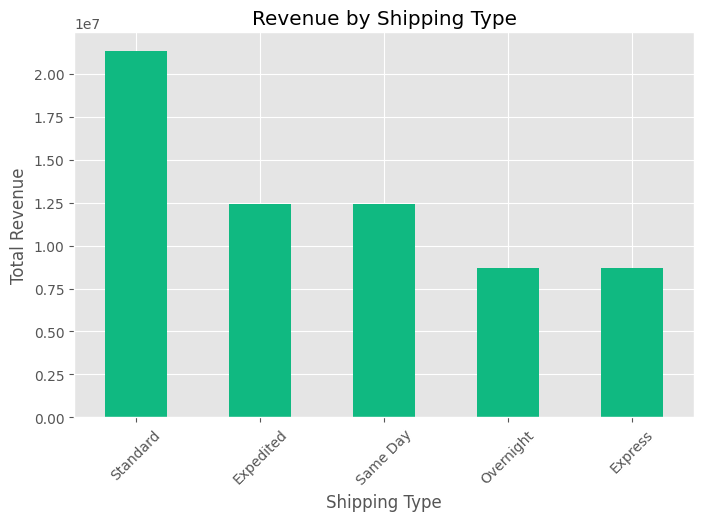

,Total Price
Shipping Type,
Standard,21343073.55
Expedited,12437526.21
Same Day,12432024.82
Overnight,8704828.17
Express,8685215.62


In [193]:
shipping_sales = df.groupby("Shipping Type")["Total Price"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
shipping_sales.plot(kind="bar", color="#10b981")
plt.title("Revenue by Shipping Type")
plt.xlabel("Shipping Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

shipping_sales


> 💡 **Insight:** Comparing revenue across product, payment, and shipping categories quickly shows *where the money comes from* — the top entry in each list is the one worth protecting and investing in first.

### 6.1 Total Price by Payment Method (spread, not just totals)
Totals only tell part of the story — a boxplot shows whether each payment method is used mostly for small or large orders, and how much that varies.

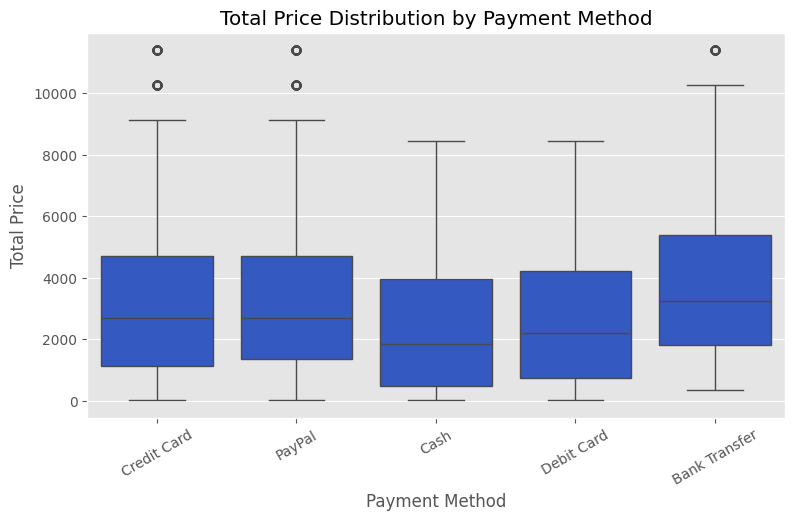

In [194]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Payment Method", y="Total Price")
plt.title("Total Price Distribution by Payment Method")
plt.xticks(rotation=30)
plt.show()


### 6.2 Average Rating by Product Type
We also check whether satisfaction differs by product — a category can generate high revenue but still have room to improve on quality/experience.

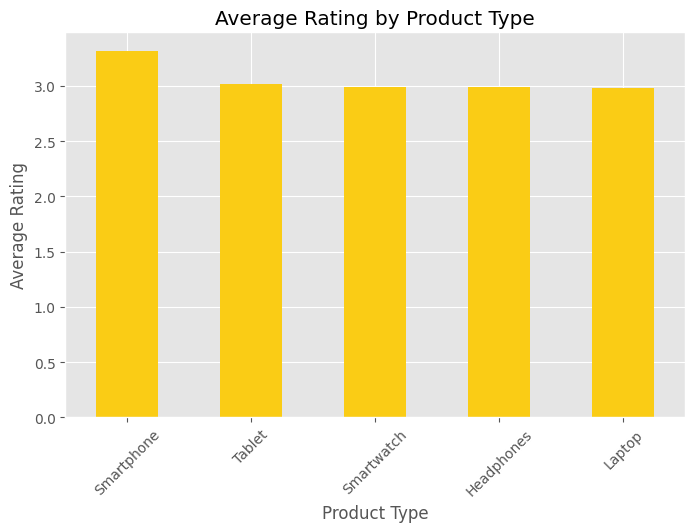

,Rating
Product Type,
Smartphone,3.319003
Tablet,3.016326
Smartwatch,2.994408
Headphones,2.993536
Laptop,2.984898


In [195]:
avg_rating = df.groupby("Product Type")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
avg_rating.plot(kind="bar", color="#facc15")
plt.title("Average Rating by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

avg_rating


> 💡 **Insight:** Product types with a lower average rating are worth a closer look — improving product descriptions or quality control there could lift satisfaction without changing price.

## 7. 👥 Customer Analysis
Finally, we look at revenue through the lens of *who* the customer is — gender, loyalty status, and age group.

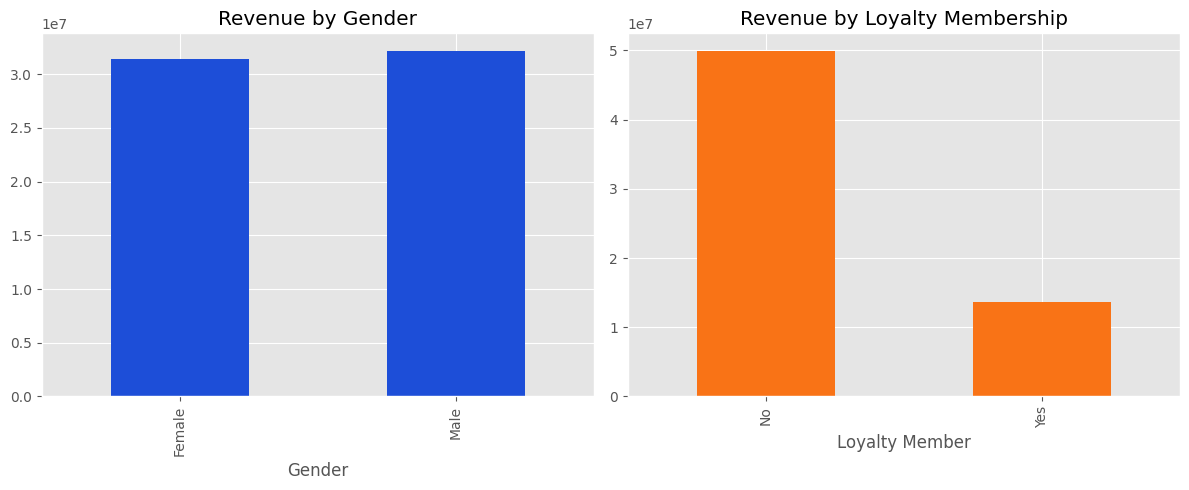

In [196]:
gender_sales = df.groupby("Gender")["Total Price"].sum()
loyalty_sales = df.groupby("Loyalty Member")["Total Price"].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gender_sales.plot(kind="bar", ax=axes[0], color="#1d4ed8")
axes[0].set_title("Revenue by Gender")

loyalty_sales.plot(kind="bar", ax=axes[1], color="#f97316")
axes[1].set_title("Revenue by Loyalty Membership")

plt.tight_layout()
plt.show()


Totals can be misleading if one group simply has more customers. Comparing the **average** order value by loyalty status is a fairer comparison.

In [197]:
loyalty_avg = df.groupby("Loyalty Member")["Total Price"].mean()
print("Average order value by loyalty status:")
loyalty_avg


Average order value by loyalty status:


,Total Price
Loyalty Member,
No,3191.974915
Yes,3137.443502


> 💡 **Insight:** If loyalty members don't show a meaningfully higher average order value, the loyalty program may need better incentives to actually drive more spend, not just enrollment.

Grouping customers into age brackets shows which age groups contribute the most revenue overall.

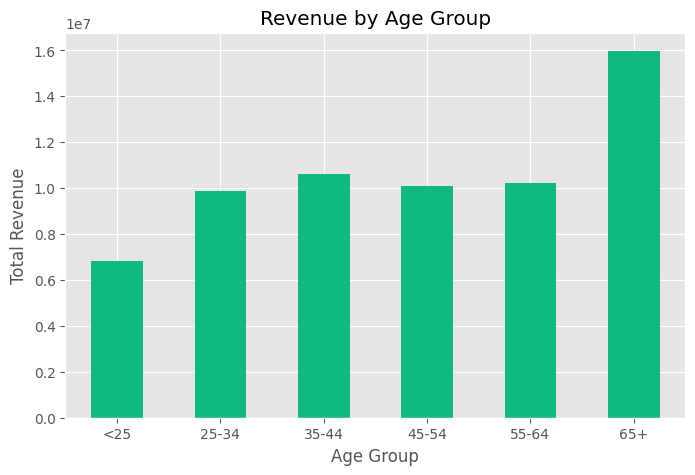

In [198]:
age_group_sales = df.groupby(pd.cut(df["Age"], bins=[0,24,34,44,54,64,120],
                                          labels=["<25","25-34","35-44","45-54","55-64","65+"]),
                              observed=True)["Total Price"].sum()

plt.figure(figsize=(8, 5))
age_group_sales.plot(kind="bar", color="#10b981")
plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()


## 8. 🔗 Correlation Analysis
A correlation matrix measures how strongly each pair of numerical columns moves together, on a scale from -1 (opposite) to +1 (identical). It's a fast way to check assumptions — for example, whether spend and satisfaction are actually related.

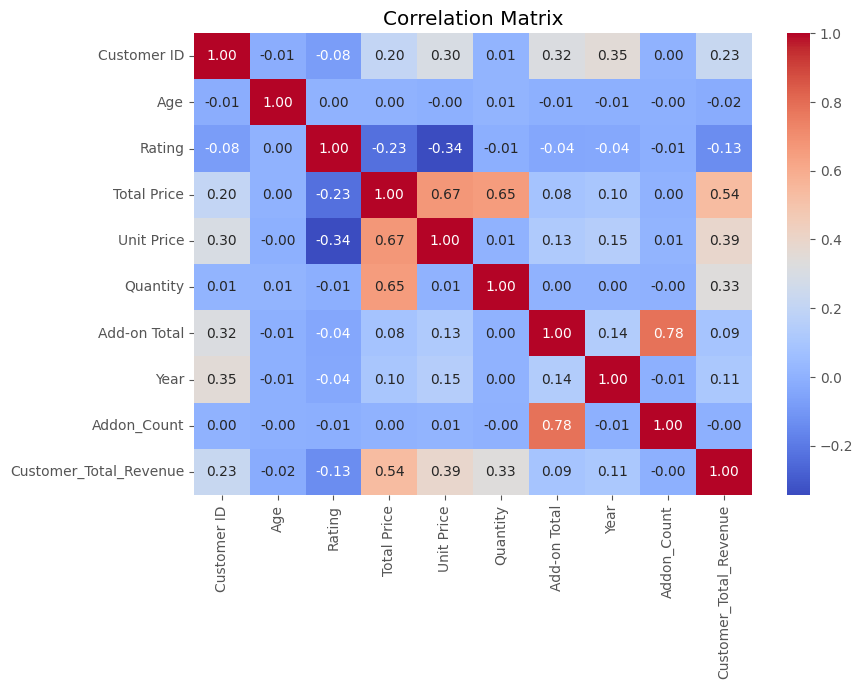

In [199]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


> 💡 **Insight:** `Rating` is only weakly correlated with the monetary columns — satisfaction doesn't simply track with how much a customer spends, so pricing and customer-experience strategies need to be managed separately.

## 9. 🎯 Final Insights & Recommendations
We close by pulling together the key numbers computed throughout the notebook into one summary, then translate them into findings and next steps for the business.

This final summary also pulls in the **Cancelled Revenue / Revenue Lost %** figures calculated in Section 5, so the cost of cancellations is visible right alongside the rest of the headline numbers — not just the cancellation rate.

In [200]:
top_product = product_sales.idxmax()
top_payment = payment_sales.idxmax()
top_shipping = shipping_sales.idxmax()
highest_month, highest_val = monthly.idxmax(), monthly.max()
lowest_month, lowest_val = monthly.idxmin(), monthly.min()
cancel_rate = (df["Order Status"] == "Cancelled").mean() * 100

print(f"Total Revenue                 : {total_revenue:,.2f}")
print(f"Highest Sales Month           : {highest_month} ({highest_val:,.2f})")
print(f"Lowest Sales Month            : {lowest_month} ({lowest_val:,.2f})")
print(f"Top Product                   : {top_product} ({product_sales.max():,.2f})")
print(f"Top Payment Method            : {top_payment} ({payment_sales.max():,.2f})")
print(f"Top Shipping Type             : {top_shipping} ({shipping_sales.max():,.2f})")
print(f"Cancellation Rate (% orders)  : {cancel_rate:.2f}%")
print(f"Cancelled Revenue             : {cancelled_revenue:,.2f} ({loss_percent:.2f}% of total revenue)")
print(f"Net Revenue                   : {net_revenue:,.2f}")


Total Revenue                 : 63,602,668.37
Highest Sales Month           : 2024-05 (6,709,042.93)
Lowest Sales Month            : 2023-09 (481,961.79)
Top Product                   : Smartphone (21,516,754.69)
Top Payment Method            : PayPal (18,998,843.99)
Top Shipping Type             : Standard (21,343,073.55)
Cancellation Rate (% orders)  : 32.84%
Cancelled Revenue             : 20,973,052.80 (32.98% of total revenue)
Net Revenue                   : 42,629,615.57



<div style="background-color:#fff7ed; border-left:6px solid #f97316; padding:20px; border-radius:8px;">
<h3>🔑 Key Findings</h3>
<blockquote>
<ul>
<li>Total sales over the period reflect strong overall business activity (see exact figure printed above).</li>
<li>Sales fluctuate month to month — the highest and lowest months (printed above) confirm a clear seasonal pattern rather than flat, steady demand.</li>
<li>The top product, payment method, and shipping type (printed above) each account for a disproportionate share of revenue.</li>
<li>The cancellation rate is not just an operational number — it translates into a concrete amount of <b>lost revenue</b> (printed above as both a dollar figure and a % of total revenue), which is what actually matters for a business case.</li>
<li>Customer rating is only weakly linked to spend — satisfaction depends on more than price.</li>
<li>Data-quality issues found and fixed — missing values and inconsistent labels like "Paypal"/"PayPal" — would have distorted these very numbers if left unresolved.</li>
</ul>
</blockquote>
</div>

<br>

<div style="background-color:#eff6ff; border-left:6px solid #2563eb; padding:20px; border-radius:8px;">
<h3>🚀 Recommendations</h3>
<blockquote>
<ol>
<li>Keep promoting the top-performing product category, since it generates the highest revenue.</li>
<li>Increase marketing activity around the lowest sales month to smooth out the seasonal dip.</li>
<li>Encourage use of the top-performing payment method where it improves conversion and reliability.</li>
<li>Keep the top shipping type well-resourced, and investigate whether other shipping types have higher cancellation rates.</li>
<li>Reducing cancellations even slightly would directly recover the revenue lost to them, quantified in Section 5 — pair this with the shipping-type cancellation check above to find the root cause.</li>
<li>Continue monitoring missing values, outliers, and inconsistent categorical labels as part of a standard monthly data-quality check.</li>
<li>Track monthly sales and growth rate regularly to catch demand shifts early.</li>
</ol>
</blockquote>
</div>

<br>

<div style="background-color:#0f172a; padding:16px; border-radius:10px; color:#f8fafc; text-align:center;">
✅ <b>Analysis complete</b> — all figures above are computed directly from the cleaned dataset and will update automatically if the notebook is re-run on new data.
</div>
